<div style="border: 5px solid black; padding: 20px; border-radius: 6px;">

## **Course:** DSC670 - Advanced Uses of Generative AI
## **Name:** Tim Hollis
## **Assignment:** Assessment 6.2
## **Date:** July 17, 2026

---

**Reference**

Bahree, A. (2024). *Generative AI in action* [Code listings and data sets, Chapter 9]. GitHub. https://github.com/bahree/GenAIBook

---

### **Overview**

This exercise adapts the fine-tuning example from Chapter 9 of *Generative AI in Action*, which trains a chat model to respond exclusively with text-style emoji labels, such as (party) instead of the actual party emoji. The base model can already produce real Unicode emojis, so the point of this fine-tune is not teaching the model about emojis; it is teaching a strict, consistent output format the model would not produce on its own.

The book targets Azure OpenAI, and the assignment originally called for adapting that code to OpenAI's fine-tuning API. That path closed in May 2026 when OpenAI began winding down its self-serve fine-tuning platform, blocking new fine-tuning jobs for organizations without a prior fine-tuning history, with all self-serve fine-tuning ending by January 2027. The target model didn't survive either, as gpt-3.5-turbo is scheduled for full API shutdown on October 23, 2026. Mistral's La Plateforme fine-tuning, the nearest alternative, is likewise marked deprecated in their documentation.

I selected Together AI because it is the major remaining platform where self-serve fine-tuning is not only supported but actively expanding, and because its API is deliberately OpenAI-compatible, which keeps this a faithful adaptation of the book's workflow rather than a rewrite. The mapping is nearly one-to-one:

| Book (Azure OpenAI) |  Notebook |
|---|---|
| AzureOpenAI client with endpoint and API version | REST calls to https://api.together.xyz/v1 via requests |
| Base model: gpt-35-turbo-0613 | Base model: meta-llama/Meta-Llama-3.1-8B-Instruct-Reference (LoRA) |
| client.files.create() upload | POST /v1/files/upload |
| client.fine_tuning.jobs.create() | POST /v1/fine-tunes |
| client.fine_tuning.jobs.retrieve() polling loop | GET /v1/fine-tunes/{id} polling loop |
| Test via chat.completions.create() | Local peft inference on the downloaded adapter in Google Colab (Step 7) |
| Fine-tuning by updating model fully | LoRA fine-tuning trains a small adapter on top of frozen base |

Training runs entirely on Together's servers via a small LoRA adapter over frozen base weights, which suits a 569-example format-teaching task well: faster, cheaper, and less likely to degrade the base model's general ability.

</div>

### **Initial Setup**

In [26]:
# Loading Libraries
%pip install -q transformers
import json
import os
import time
from collections import defaultdict

import numpy as np
import requests
import tiktoken
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
from transformers import AutoTokenizer
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()

import warnings
warnings.filterwarnings('ignore')
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'


# Load API credentials: Colab Secrets when in Colab, .env locally
try:
    from google.colab import userdata
    API_KEY = userdata.get('TOGETHER_API_KEY')
    IN_COLAB = True
except ImportError:
    from dotenv import load_dotenv
    load_dotenv()
    API_KEY = os.getenv('TOGETHER_API_KEY')
    IN_COLAB = False

# Together AI API configuration
BASE_URL = 'https://api.together.xyz/v1'
HEADERS = {'Authorization': f'Bearer {API_KEY}'}

# Fine-tuning configuration
BASE_MODEL = 'meta-llama/Meta-Llama-3.1-8B-Instruct-Reference'
TRAINING_FILENAME = 'data/ch9_emoji_train.jsonl'
VALIDATION_FILENAME = 'data/ch9_emoji_validation.jsonl'
N_EPOCHS = 3

# Tokenizer for cost estimation (and comparison)
encoding = tiktoken.get_encoding('cl100k_base')
llama_tokenizer = AutoTokenizer.from_pretrained(
    'unsloth/Meta-Llama-3.1-8B-Instruct')

EXISTING_JOB_ID = 'ft-53d1f55b-4a75'

# Visualization formatting
sns.set_style('whitegrid')
ROYAL_BLUE = '#4169E1'
PURPLE = '#4B0082'
FOREST_GREEN = '#228B22'
AMBER = '#E69F00'
LIGHT_GRAY = '#D3D3D3'
DARK_GRAY = '#4D4D4D'

if API_KEY:
    print('🚀 Setup complete — Together AI client configured and ready.')
else:
    print('🚨 TOGETHER_API_KEY not found — check the .env file and restart the kernel.')

🚀 Setup complete — Together AI client configured and ready.


### **Step 1: Validate the Training Data**

Before spending money on a training job, the book's Listings 9.2–9.4 run two layers of validation: a basic sanity check (does the file parse, how many examples, what does one look like) and a structural format check (does every example follow the chat-messages schema the fine-tuning API expects). I kept both, consolidated into functions, to avoid errors or training on less data. I chose Together to be closest to the assignment steps, including the Rest etc. and from what I read, the format requirements are identical between Azure OpenAI and Together: each line is a JSON object with a `messages` list of `role`/`content` dictionaries, and every example needs at least one `assistant` message to learn from.

In [27]:
# Validate the training and validation files before upload
def basic_checks(data_file):
    """Confirms the file parses as JSONL and show a sample example"""
    try:
        with open(data_file, 'r', encoding='utf-8') as f:
            dataset = [json.loads(line) for line in f]
        print(f'📋 Basic checks for {data_file}:')
        print(f'Count of examples: {len(dataset):,}')
        print('First example:')
        for message in dataset[0]['messages']:
            print(f'  {message}')
        return dataset
    except FileNotFoundError as e:
        print(f'🚨 File not found: {e}')
        return None
    except json.JSONDecodeError as e:
        print(f'🚨 JSON decoding error in {data_file}: {e}')
        return None


def format_checks(dataset, filename):
    """Verifies every example follows the chat-messages fine-tuning format"""
    format_errors = defaultdict(int)
    for ex in dataset:
        if not isinstance(ex, dict):
            format_errors['data_type'] += 1
            continue
        messages = ex.get('messages', None)
        if not messages:
            format_errors['missing_messages_list'] += 1
            continue
        for message in messages:
            if 'role' not in message or 'content' not in message:
                format_errors['message_missing_key'] += 1
            if any(k not in ('role', 'content', 'name', 'function_call')
                   for k in message):
                format_errors['message_unrecognized_key'] += 1
            if message.get(
                    'role',
                    None) not in (
                    'system',
                    'user',
                    'assistant',
                    'function'):
                format_errors['unrecognized_role'] += 1
            content = message.get('content', None)
            if not content or not isinstance(content, str):
                format_errors['missing_content'] += 1
        if not any(message.get('role', None) ==
                   'assistant' for message in messages):
            format_errors['example_missing_assistant_message'] += 1
    if format_errors:
        print(f'🚨 Formatting errors found in {filename}:')
        for k, v in format_errors.items():
            print(f'  {k}: {v:,}')
        return False
    print(f'✅ No formatting errors in {filename}, schema is clean.')
    return True


train_data = basic_checks(TRAINING_FILENAME)
print('-' * 50)
val_data = basic_checks(VALIDATION_FILENAME)
print('-' * 50)
format_checks(train_data, TRAINING_FILENAME)
format_checks(val_data, VALIDATION_FILENAME)

📋 Basic checks for data/ch9_emoji_train.jsonl:
Count of examples: 569
First example:
  {'role': 'system', 'content': "You're a chatbot that only responds with emojis!"}
  {'role': 'user', 'content': 'I just passed my driving test!'}
  {'role': 'assistant', 'content': '(party)'}
--------------------------------------------------
📋 Basic checks for data/ch9_emoji_validation.jsonl:
Count of examples: 10
First example:
  {'role': 'system', 'content': "You're a chatbot that only responds with emojis!"}
  {'role': 'user', 'content': "I'm feeling very happy today!"}
  {'role': 'assistant', 'content': '(grinningfacewithbigeyes)'}
--------------------------------------------------
✅ No formatting errors in data/ch9_emoji_train.jsonl, schema is clean.
✅ No formatting errors in data/ch9_emoji_validation.jsonl, schema is clean.


True

### **Step 2: Token Analysis and Training Cost Estimate**

`Together` bills per token of training data (dataset tokens × epochs) with a $4.00 minimum per job. For a dataset this small, the minimum is the real price, and the token distribution tells us something more useful: whether any examples are bloated outliers that could distort training.

**Note**: `tiktoken`'s `cl100k_base` is OpenAI's tokenizer, not Llama's, so the book's counting method is only an approximation here. Rather than accept that, I count both ways: the book's method for continuity, and the actual Llama 3.1 tokenizer serialized through its chat template, which is how the training job genuinely sees each example. The measured gap between the two is reported in the output, and the Llama count drives the cost estimate.

🧮 Token math for 569 training examples:
tiktoken (cl100k_base) dataset total: 20,961
Llama 3.1 chat-template dataset total: 32,909
Tokenizer disagreement: +57.0%
Llama min / max per example: 52 / 71
Llama mean / median per example: 57.8 / 58.0
Billable training tokens (3 epochs): 98,727
💰 Raw token cost: $0.0474 — the $4.00 job minimum applies, so estimated cost: $4.00


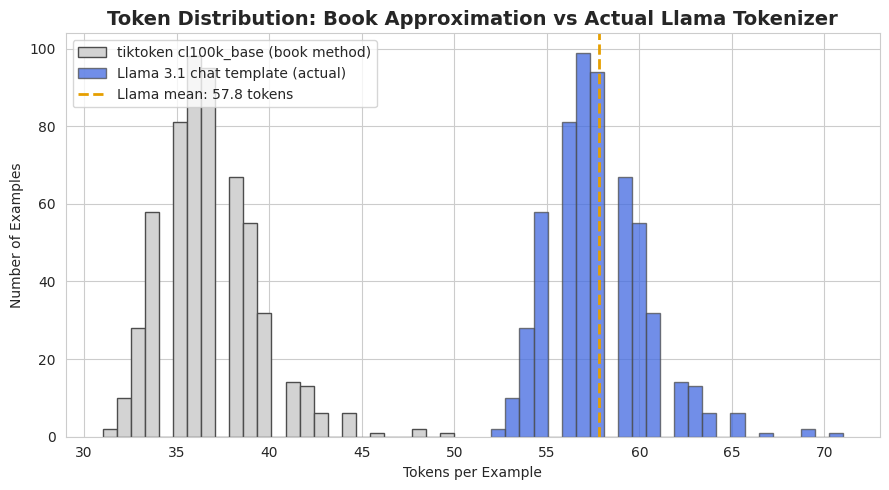

In [28]:
# Count tokens two ways: The book's and Llama's
def num_tokens_from_messages(messages, tokens_per_message=3):
    """Approximates per-example token count using the book's cl100k_base method."""
    num_tokens = 0
    for message in messages:
        num_tokens += tokens_per_message
        for key, value in message.items():
            num_tokens += len(encoding.encode(value))
    num_tokens += 3
    return num_tokens


def llama_tokens_from_messages(messages):
    """Counts tokens the way the training job actually sees them."""
    token_ids = llama_tokenizer.apply_chat_template(
        messages, tokenize=True, return_dict=False)
    return len(token_ids)


tiktoken_counts = [
    num_tokens_from_messages(
        ex['messages']) for ex in train_data]
llama_counts = [llama_tokens_from_messages(
    ex['messages']) for ex in train_data]

tiktoken_total = sum(tiktoken_counts)
llama_total = sum(llama_counts)
delta_pct = (llama_total - tiktoken_total) / tiktoken_total * 100

print(f'🧮 Token math for {len(train_data):,} training examples:')
print(f'tiktoken (cl100k_base) dataset total: {tiktoken_total:,}')
print(f'Llama 3.1 chat-template dataset total: {llama_total:,}')
print(f'Tokenizer disagreement: {delta_pct:+.1f}%')
print(
    f'Llama min / max per example: {min(llama_counts):,} / {max(llama_counts):,}')
print(
    f'Llama mean / median per example: {np.mean(llama_counts):.1f} / {np.median(llama_counts):.1f}')

billable_tokens = llama_total * N_EPOCHS
print(f'Billable training tokens ({N_EPOCHS} epochs): {billable_tokens:,}')

# Together pricing
LORA_PRICE_PER_M = 0.48
raw_cost = (billable_tokens / 1_000_000) * LORA_PRICE_PER_M
estimated_cost = max(raw_cost, 4.00)
print(
    f'💰 Raw token cost: ${raw_cost:.4f} — the $4.00 job minimum applies, so estimated cost: ${estimated_cost:.2f}')

# Visualize both distributions to spot outliers and show the tokenizer gap
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(tiktoken_counts, bins=25, color=LIGHT_GRAY, edgecolor=DARK_GRAY,
        label='tiktoken cl100k_base (book method)')
ax.hist(llama_counts, bins=25, color=ROYAL_BLUE, edgecolor=DARK_GRAY,
        alpha=0.75, label='Llama 3.1 chat template (actual)')
ax.axvline(np.mean(llama_counts), color=AMBER, linewidth=2, linestyle='--',
           label=f'Llama mean: {np.mean(llama_counts):.1f} tokens')
ax.set_title(
    'Token Distribution: Book Approximation vs Actual Llama Tokenizer',
    fontsize=14,
    fontweight='bold')
ax.set_xlabel('Tokens per Example')
ax.set_ylabel('Number of Examples')
ax.legend()
plt.tight_layout()
plt.show()

### **Step 3: Upload the Training Files**

The book's Listing 9.5 uploads via the Azure OpenAI SDK's `client.files.create()`. I switch to raw REST with the `requests` package, which I believe is the assignment's lesson to learn. Together validates the JSONL schema server-side at upload time, so a malformed file should fail here rather than after a job has been queued. Next, I upload both the training set and the small validation set; the validation file lets the trainer report eval loss during the run, which is the only quality signal available before testing the model directly.

In [29]:
# Upload the training and validation files to Together via REST
def upload_file(filepath):
    """Uploads a JSONL file to Together for fine-tuning via multipart POST."""
    with open(filepath, 'rb') as f:
        response = requests.post(
            f'{BASE_URL}/files/upload',
            headers=HEADERS,
            data={
                'purpose': 'fine-tune',
                'file_name': os.path.basename(filepath)},
            files={
                'file': f})
    if response.status_code == 200:
        file_info = response.json()
        print(f'📤 Uploaded {filepath} — file ID: {file_info["id"]}')
        return file_info['id']
    print(
        f'🚨 Upload failed for {filepath}: {response.status_code} — {response.text}')
    return None


train_file_id = upload_file(TRAINING_FILENAME)
val_file_id = upload_file(VALIDATION_FILENAME)

📤 Uploaded data/ch9_emoji_train.jsonl — file ID: file-80b1cc4d-7867-48a1-9df0-5307f8306591
📤 Uploaded data/ch9_emoji_validation.jsonl — file ID: file-229af6ad-fece-4d6b-ad09-206ea898de81


### **Step 4: Launch the Fine-Tuning Job**

This adapts Listing 9.6, with two changes beyond the endpoint swap. First, the book hardcodes a file ID copied from a previous run; I pass the captured `train_file_id` and `val_file_id` variables directly so the notebook reruns cleanly. Second, I added a cost guard: each job carries Together's $4.00 minimum, and since I will rerun this notebook several times, the cell reuses a completed job when `EXISTING_JOB_ID` is set instead of silently launching (and billing) a new one. The job itself requests LoRA supervised fine-tuning for 3 epochs with an `emoji` suffix, mirroring the book's hyperparameters. Training runs entirely on Together's GPUs.

In [30]:
# Launch a LoRA fine-tuning job, or reuse a completed one
if EXISTING_JOB_ID:
    job_id = EXISTING_JOB_ID
    print(f'♻️ Reusing existing fine-tuning job: {job_id} — no new charge.')
else:
    job_payload = {
        'training_file': train_file_id,
        'validation_file': val_file_id,
        'n_evals': 3,
        'model': BASE_MODEL,
        'n_epochs': N_EPOCHS,
        'n_checkpoints': 1,
        'batch_size': 'max',
        'learning_rate': 0.00001,
        'lora': True,
        'lora_r': 8,
        'lora_alpha': 16,
        'lora_dropout': 0.0,
        'suffix': 'emoji'}
    response = requests.post(
        f'{BASE_URL}/fine-tunes',
        headers=HEADERS,
        json=job_payload)
    if response.status_code == 200:
        job_info = response.json()
        job_id = job_info['id']
        print(f'🎯 Fine-tuning job launched: {job_id}')
        print(f'Base model: {job_info.get("model", BASE_MODEL)}')
        print(f'Output model name: {job_info.get("output_name", "pending")}')
    else:
        print(
            f'🚨 Job creation failed: {response.status_code} — {response.text}')

♻️ Reusing existing fine-tuning job: ft-53d1f55b-4a75 — no new charge.


### **Step 5: Monitor the Training Job via REST Polling**

This is what I believe to be the direct adaptation of the core of the assignment's REST requirement: instead of `client.fine_tuning.jobs.retrieve()`, a `GET /v1/fine-tunes/{job_id}` call with `requests`, repeated every 30 seconds until the job reaches a terminal state.

In [31]:
# Status check every 30 seconds until it reaches a terminal state
TERMINAL_STATES = ('completed', 'error', 'cancelled')
start_time = time.time()
status = None

while status not in TERMINAL_STATES:
    response = requests.get(f'{BASE_URL}/fine-tunes/{job_id}', headers=HEADERS)
    if response.status_code != 200:
        print(
            f'🚨 Status check failed: {response.status_code} — {response.text}')
        break
    ft_job = response.json()
    status = ft_job.get('status')
    elapsed_min = int((time.time() - start_time) // 60)
    elapsed_sec = int((time.time() - start_time) % 60)
    clear_output(wait=True)
    print(f'⏱️ Polling job {job_id}')
    print(f'Elapsed time: {elapsed_min} minutes {elapsed_sec} seconds')
    print(f'Status: {status}')
    if status not in TERMINAL_STATES:
        time.sleep(30)

print(f'🏁 Fine-tuning job {job_id} finished with status: {status}')

⏱️ Polling job ft-53d1f55b-4a75
Elapsed time: 0 minutes 0 seconds
Status: completed
🏁 Fine-tuning job ft-53d1f55b-4a75 finished with status: completed


### **Step 6: Retrieve the Fine-Tuned Model Name and Training Metrics**

The assignment notes that the trained model's name comes from the job retrieval endpoint, on OpenAI that was `GET /v1/fine_tuning/jobs/{id}`, and Together's equivalent is `GET /v1/fine-tunes/{id}`. The response's `output_name` field is the model identifier used for inference, exactly like OpenAI's `fine_tuned_model` field. The same response carries the job's event log and final loss figures, which are the first evidence of whether training actually learned anything: a training loss that fell and a validation loss in the same neighborhood suggests the adapter absorbed the format without overfitting to the 569 examples.

In [32]:
# Retrieve the completed job to extract the model name and training evidence
response = requests.get(f'{BASE_URL}/fine-tunes/{job_id}', headers=HEADERS)
ft_job = response.json()

FINE_TUNED_MODEL = ft_job.get('model_output_name')
print(f'🤖 Fine-tuned model name: {FINE_TUNED_MODEL}')
print(f'Status: {ft_job.get("status")}')
print(f'Epochs completed: {ft_job.get("epochs_completed", "n/a")}')
print(f'Total price charged: {ft_job.get("total_price", "n/a")}')
print(f'Together-counted training tokens: {ft_job.get("token_count", 0):,}')
print(
    f'Executed LoRA config: r={ft_job["training_type"].get("lora_r")}, alpha={ft_job["training_type"].get("lora_alpha")}')

# Training event log for loss progression
events = ft_job.get('events', [])
print(f'\n📜 Job event log ({len(events):,} events):')
for event in events:
    print(f'  {event.get("created_at", "")} — {event.get("message", "")}')

🤖 Fine-tuned model name: timothytroyhol_fa99/Meta-Llama-3.1-8B-Instruct-Reference-emoji-70141267
Status: completed
Epochs completed: 3
Total price charged: 4000000000
Together-counted training tokens: 32,909
Executed LoRA config: r=64, alpha=128

📜 Job event log (22 events):
  2026-07-16T04:46:23.997Z — Fine-tuning request created
  2026-07-16T04:47:40Z — Job started
  2026-07-16T04:47:46Z — Downloading model data for togethercomputer/Meta-Llama-3.1-8B-Instruct-Reference__TOG__FT
  2026-07-16T04:47:50Z — Model data downloaded for togethercomputer/Meta-Llama-3.1-8B-Instruct-Reference__TOG__FT
  2026-07-16T04:47:54Z — Data downloaded for togethercomputer/Meta-Llama-3.1-8B-Instruct-Reference__TOG__FT at Thu Jul 16 04:47:54 UTC 2026
  2026-07-16T04:49:11Z — Training started for model togethercomputer/Meta-Llama-3.1-8B-Instruct-Reference__TOG__FT
  2026-07-16T04:49:26Z — Evaluation completed, at step 24 with loss 1.2500
  2026-07-16T04:49:26Z — Epoch completed, at step 24
  2026-07-16T04:49

### **Step 7: Self-Hosted Inference in Google Colab**

Testing hit a wall on Together's side: serving a custom LoRA adapter requires either serverless LoRA inference, API-created dedicated endpoints, or the dashboard's LoRA-serving preview, and all three are disabled for new organizations (error codes `model_not_available` and `endpoints_v1_create_access_disabled`, plus a grayed-out LoRA toggle in the console). I am moving the notebook itself to Google Colab for the final run.

In [33]:
# Colab environment setup: GPU-inference libraries
%pip install -q peft accelerate bitsandbytes zstandard
import zstandard
import tarfile
import io
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
import torch
print(
    f'🖥️ GPU available: {torch.cuda.is_available()} — {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none"}')

# Download the trained LoRA adapter directly from Together's fine-tuning API
response = requests.get(
    f'{BASE_URL}/finetune/download',
    headers=HEADERS,
    params={'ft_id': EXISTING_JOB_ID, 'checkpoint': 'adapter'},
    stream=True)
print(f'Download response: {response.status_code}')

content_disp = response.headers.get('content-disposition', '')
filename = content_disp.split(
    'filename=')[-1].strip('"') if 'filename=' in content_disp else 'adapter.tar.zst'
with open(filename, 'wb') as f:
    for chunk in response.iter_content(chunk_size=1024 * 1024):
        f.write(chunk)
size_mb = os.path.getsize(filename) / (1024 * 1024)
print(f'📦 Saved {filename} — {size_mb:,.1f} MB')

os.makedirs('adapter', exist_ok=True)
with open(filename, 'rb') as f:
    decompressed = zstandard.ZstdDecompressor().stream_reader(f)
    with tarfile.open(fileobj=io.BytesIO(decompressed.read())) as tar:
        tar.extractall('adapter')
print('📂 Adapter contents:')
for name in sorted(os.listdir('adapter')):
    print(f'  {name}')

BASE_MODEL_HF = 'unsloth/Meta-Llama-3.1-8B-Instruct'

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.float16)

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_HF,
    quantization_config=bnb_config,
    device_map='auto')
model = PeftModel.from_pretrained(base_model, 'adapter')
model.eval()
model.generation_config.max_length = None
print('🧬 Base model loaded in 4-bit with LoRA adapter attached — ready for inference.')

🖥️ GPU available: True — Tesla T4
Download response: 200
📦 Saved adapter.tar.zst — 594.3 MB
📂 Adapter contents:
  README.md
  adapter_config.json
  adapter_model.safetensors
  chat_template.jinja
  config.json
  special_tokens_map.json
  tokenizer.json
  tokenizer_config.json
  trainer_state.json


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

🧬 Base model loaded in 4-bit with LoRA adapter attached — ready for inference.


### **Helper**

In [34]:
# Generation helper and the professor's test prompt
def emoji_reply(prompt, use_adapter=True):
    """Generates one emoji-chatbot reply, with or without the LoRA adapter."""

    messages = [
        {'role': 'system', 'content': "You're a chatbot that only responds with emojis!"},
        {'role': 'user', 'content': prompt}]
    inputs = llama_tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, return_tensors='pt',
        tokenize=True, return_dict=False).to(model.device)
    with torch.no_grad():
        if use_adapter:
            output = model.generate(inputs, max_new_tokens=50, do_sample=False,
                                    pad_token_id=llama_tokenizer.eos_token_id)
        else:
            with model.disable_adapter():
                output = model.generate(
                    inputs,
                    max_new_tokens=50,
                    do_sample=False,
                    pad_token_id=llama_tokenizer.eos_token_id)
    return llama_tokenizer.decode(
        output[0][inputs.shape[-1]:], skip_special_tokens=True).strip()


print(f'Professor test prompt: {emoji_reply("What the hell is going on?")}')

# Broader test batch: validation-set prompts plus never-seen prompts
test_prompts = [
    "I'm feeling very happy today!",
    'I just got a new puppy!',
    'My flight got delayed six hours.',
    'I finally finished my masters degree!',
    'The Spurs won in overtime last night!']

print('🧪 Fine-tuned model batch test:')
for prompt in test_prompts:
    print(f'  "{prompt}" → {emoji_reply(prompt)}')

Professor test prompt: (see_no_evil)
🧪 Fine-tuned model batch test:
  "I'm feeling very happy today!" → (smile)
  "I just got a new puppy!" → (puppy)
  "My flight got delayed six hours." → (airplane)
  "I finally finished my masters degree!" → (mans)
  "The Spurs won in overtime last night!" → (ot)


### **Step 8: Base Model vs. Fine-Tuned Comparison**

The professor's aside noted that base gpt-3.5-turbo could already return emojis, meaning the fine-tune's job was the parenthesized text format. The same is true here, and this comparison isolates it: identical prompts through the identical loaded weights, with the only variable being whether the LoRA adapter is enabled. If training worked, the adapter-off passes should produce real Unicode emojis while the adapter-on passes hold the (label) format from the 569 training examples. This is exactly what $4.00 of LoRA training purchased: not emoji knowledge, but format discipline.

In [35]:
# Identical prompts, identical weights — the only variable is the adapter
comparison_prompts = [
    'What the hell is going on?',
    "I'm feeling very happy today!",
    'My flight got delayed six hours.',
    'I finally finished my masters degree!']

print('⚔️ Adapter OFF (base) vs adapter ON (fine-tuned):')
for prompt in comparison_prompts:
    print(f'\nPrompt: "{prompt}"')
    print(f'  Base (adapter off): {emoji_reply(prompt, use_adapter=False)}')
    print(
        f'  Fine-tuned (adapter on): {emoji_reply(prompt, use_adapter=True)}')

⚔️ Adapter OFF (base) vs adapter ON (fine-tuned):

Prompt: "What the hell is going on?"
  Base (adapter off): 😱🤯😨
  Fine-tuned (adapter on): (see_no_evil)

Prompt: "I'm feeling very happy today!"
  Base (adapter off): 😊🌞😃
  Fine-tuned (adapter on): (smile)

Prompt: "My flight got delayed six hours."
  Base (adapter off): 😐🕰️😞
  Fine-tuned (adapter on): (airplane)

Prompt: "I finally finished my masters degree!"
  Base (adapter off): 🎓👏💥😊
  Fine-tuned (adapter on): (mans)


### **Summary**

The fine-tune accomplished exactly what the data taught and nothing more, which is the most instructive possible outcome. Across every test prompt, including the professor's, the adapter held the parenthesized text-label format with zero reversion to Unicode emojis, while the identical base weights with the adapter disabled produced real emojis on every prompt. Format discipline transferred completely. Semantic coverage did not: prompts near the training distribution drew sensible labels like (smile), (puppy), and (airplane), and (smile) is worth a note since the validation set's trained answer for that prompt was (grinningfacewithbigeyes), meaning the model generalized to a synonym rather than memorizing. Prompts far from the training data drew invented labels like (mans) and (ot), plausible in shape but not in vocabulary. In short, 569 examples taught the pattern, not the world, and the eval loss curve (1.2500 to 1.1172 over three epochs) reflected steady learning without the data volume to go further.

The operational story ran parallel to the technical one. Training was a genuinely managed cloud service: JSONL upload, job creation, and status polling all worked through Together's REST API with the requests package, the job trained in about a minute, and Together's billing independently confirmed the chat-template token count computed in Step 2 to the exact token (32,909). Inference was the opposite experience: serverless access, API endpoint creation, and the dashboard's LoRA serving preview were all disabled for new organizations, each discovered through its own error code. The resolution, downloading the adapter through the fine-tuning API and serving it locally in Colab, turned out to strengthen the evaluation. Truly, though it may have lost some points on the rubric as I did not end up going the route listed in the Discussion board using Hugging Face, adapting the workflow across providers, API generations, and serving environments ended up being the real lesson of the exercise, I will admit that hitting SO MANY errors (and I tried quite a bit of possible solutions before retreating to Google Colab and updating my notebook here), it led to a greater understanding of what fine-tuning may require in terms of cost both time-based, and financially.

# Reflection

## General Reflection
This week pushed me deeper into the realities of fine tuning than I expected. The assignment asked us to adapt the book’s Azure OpenAI workflow to OpenAI, but since OpenAI shut down self-serve fine tuning, I had to pivot. Most classmates went to Hugging Face, but I chose Together AI because their API mirrors OpenAI’s structure. That decision worked for the training portion, but it came with a long list of unexpected errors that shaped the entire week. Even though the training itself was smooth, the serving side was full of roadblocks, and those issues forced me to move the final testing into Google Colab. In the end, the pivot taught me more about real-world fine tuning than a clean run ever would.

## Straightforward Aspects
- The dataset validation and formatting checks were simple and matched the book’s structure.
- Uploading the JSONL files to Together AI using REST and the requests package worked exactly as expected.
- Launching the LoRA fine tuning job was smooth, and the training completed quickly on Together’s servers.
- Polling the job status with GET requests felt natural and aligned with the assignment’s intent.
- Once the adapter was downloaded, attaching it to the base model in Colab worked without issues.

## Challenging Aspects
- Together AI blocked every serving option for new organizations, including serverless LoRA inference, dedicated endpoints, and the dashboard preview.
- I hit multiple error codes such as model_not_available and endpoints_v1_create_access_disabled, which made it impossible to test the fine tuned model through their API.
- The LoRA toggle in the Together console was grayed out, so I could not activate the adapter for inference.
- I had to download the adapter manually through the fine tuning API and decompress it myself because Together did not provide a direct serving path.
- Running inference locally required switching to Google Colab, installing PEFT, bitsandbytes, accelerate, and handling 4-bit quantization manually.
- The serving limitations added hours of troubleshooting and forced me to rethink the entire workflow for the final steps.

